In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report

In [2]:
train_dir = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon/FruitinAmazon/train"
test_dir  = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon/FruitinAmazon/test"


IMG_HEIGHT          = 128
IMG_WIDTH           = 128
BATCH_SIZE          = 16
VAL_SPLIT           = 0.2
EPOCHS              = 250
EARLY_STOP_PATIENCE = 15


Task 1: Data Understanding and Visualization:

Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

Scanning file types in each class folder:
  acai: 15 files | extensions found: {'.jpeg'}
  cupuacu: 11 files | extensions found: {'.jpeg'}
  graviola: 0 files | extensions found: set()
  guarana: 0 files | extensions found: set()
  pupunha: 15 files | extensions found: {'.jpeg'}
  tucuma: 15 files | extensions found: {'.jpeg'}


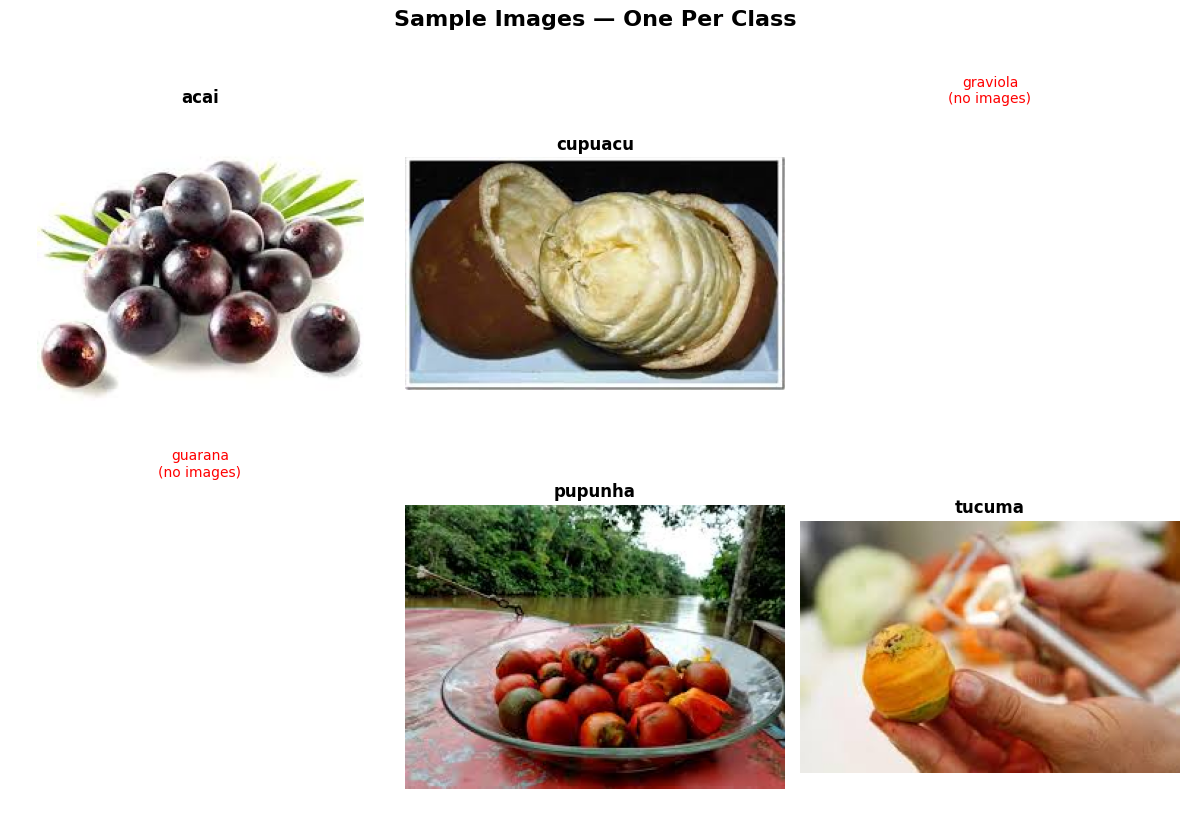


Observation:
  • Images belong to different Amazonian fruit classes.
  • They vary in colour, texture, shape, and background.
  • Some classes may be harder to distinguish than others.



In [5]:
def visualise_classes(train_dir):
    class_dirs = sorted([
        d for d in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, d))
    ])
    print(f"Classes found ({len(class_dirs)}): {class_dirs}")

    print("\nScanning file types in each class folder:")
    for cls in class_dirs:
        cls_path = os.path.join(train_dir, cls)
        all_files = os.listdir(cls_path)
        extensions = set(os.path.splitext(f)[1].lower() for f in all_files if os.path.isfile(os.path.join(cls_path, f)))
        print(f"  {cls}: {len(all_files)} files | extensions found: {extensions}")

    VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp'}

    num_classes = len(class_dirs)
    cols = (num_classes + 1) // 2
    rows = 2

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for idx, cls in enumerate(class_dirs):
        cls_path = os.path.join(train_dir, cls)

        images = [
            f for f in os.listdir(cls_path)
            if os.path.splitext(f)[1].lower() in VALID_EXTS
            and os.path.isfile(os.path.join(cls_path, f))
        ]

        if not images:
            print(f"  WARNING: No valid images found in '{cls}' — skipping.")
            axes[idx].set_title(f"{cls}\n(no images)", fontsize=10, color='red')
            axes[idx].axis('off')
            continue

        img_path = os.path.join(cls_path, random.choice(images))
        img      = Image.open(img_path).convert('RGB')   # convert ensures it renders correctly
        axes[idx].imshow(img)
        axes[idx].set_title(cls, fontsize=12, fontweight='bold')
        axes[idx].axis('off')

    for ax in axes[num_classes:]:
        ax.axis('off')

    plt.suptitle("Sample Images — One Per Class", fontsize=16,
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print("\nObservation:")
    print("  • Images belong to different Amazonian fruit classes.")
    print("  • They vary in colour, texture, shape, and background.")
    print("  • Some classes may be harder to distinguish than others.\n")

visualise_classes(train_dir)

In [6]:
def remove_corrupted_images(train_dir):
    corrupted = []
    class_dirs = [
        d for d in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, d))
    ]

    for cls in class_dirs:
        cls_path = os.path.join(train_dir, cls)
        for fname in os.listdir(cls_path):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            img_path = os.path.join(cls_path, fname)
            try:
                img = Image.open(img_path)
                img.verify()
            except (IOError, SyntaxError):
                corrupted.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

    if not corrupted:
        print("No Corrupted Images Found.")
    else:
        print(f"\nTotal corrupted images removed: {len(corrupted)}")

remove_corrupted_images(train_dir)

No Corrupted Images Found.


Task2: LoadingandPreprocessingImageDatainkeras:

In [7]:
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (IMG_HEIGHT, IMG_WIDTH),
    interpolation    = 'nearest',
    batch_size       = BATCH_SIZE,
    shuffle          = True,
    validation_split = VAL_SPLIT,
    subset           = 'training',
    seed             = 123
)

Found 56 files belonging to 6 classes.
Using 45 files for training.


In [8]:
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (IMG_HEIGHT, IMG_WIDTH),
    interpolation    = 'nearest',
    batch_size       = BATCH_SIZE,
    shuffle          = False,
    validation_split = VAL_SPLIT,
    subset           = 'validation',
    seed             = 123
)

Found 56 files belonging to 6 classes.
Using 11 files for validation.


In [9]:
class_names = train_ds_raw.class_names
num_classes = len(class_names)
print(f"\nClass names : {class_names}")
print(f"Num classes : {num_classes}")



Class names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6


In [10]:
rescale  = tf.keras.layers.Rescaling(1.0 / 255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (train_ds_raw
            .map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
            .cache()
            .prefetch(AUTOTUNE))

val_ds   = (val_ds_raw
            .map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
            .cache()
            .prefetch(AUTOTUNE))

Task 3- Implement a CNN with

In [11]:
model = keras.Sequential([

    layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        strides     = (1, 1),
        padding     = 'same',
        activation  = 'relu',
        input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        strides     = (1, 1),
        padding     = 'same',
        activation  = 'relu'
    ),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(num_classes, activation='softmax')

], name="Fruit_CNN")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Fruit_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile the Model

In [12]:
model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

Task 4: Train the Model

In [13]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath       = 'best_model.h5',
    monitor        = 'val_accuracy',
    save_best_only = True,
    verbose        = 1
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = EARLY_STOP_PATIENCE,
    restore_best_weights = True,
    verbose              = 1
)

In [14]:
print("\nStarting training (max 250 epochs, EarlyStopping patience=15)...\n")
history = model.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = val_ds,
    callbacks       = [checkpoint_cb, early_stop_cb]
)


Starting training (max 250 epochs, EarlyStopping patience=15)...

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.1708 - loss: 3.1457
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 532ms/step - accuracy: 0.2000 - loss: 3.6524 - val_accuracy: 0.0000e+00 - val_loss: 2.6465
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.2600 - loss: 1.8940
Epoch 2: val_accuracy improved from 0.00000 to 1.00000, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 389ms/step - accuracy: 0.3111 - loss: 1.7438 - val_accuracy: 1.0000 - val_loss: 1.1450
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.5722 - loss: 1.2802
Epoch 3: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 309ms/step - accuracy: 0.4667 - loss: 1.3347 - val_accuracy: 0.1818 - val_loss: 1.2393
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.4590 - loss: 1.2110
Epoch 4: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/step - accuracy: 0.5333 - loss: 1.2027 - val_accuracy: 0.6364 - val_loss: 1.1755
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.6866 - loss: 0.9474
Epoch 5: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step - accuracy: 0.6222 - loss: 0.9653 - val_accuracy: 1.0000 - val_loss: 0.7548
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9495 - loss: 0.655

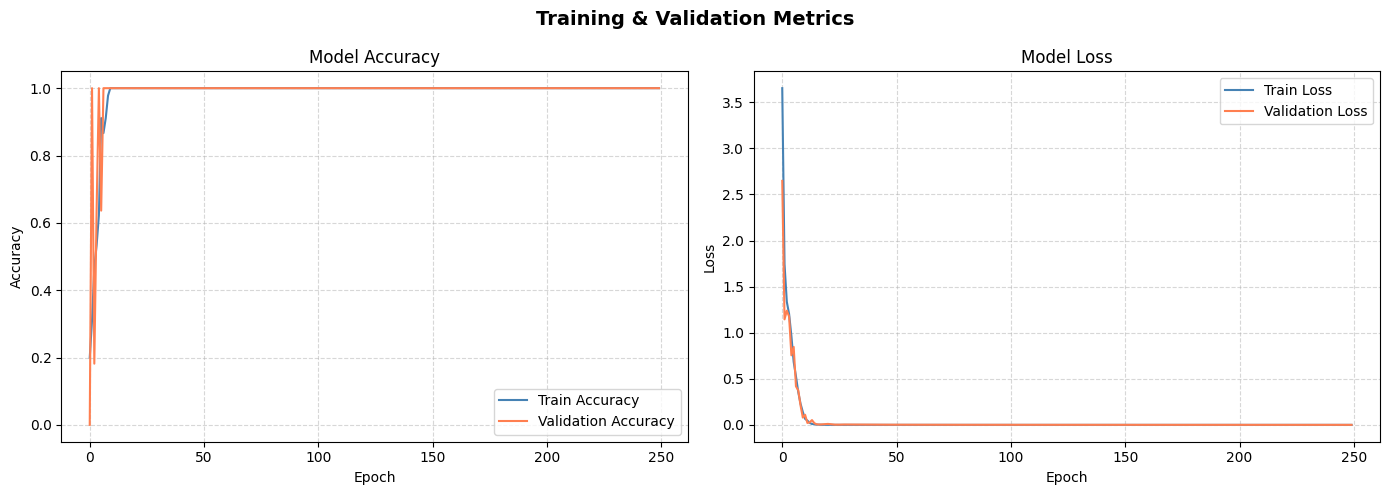

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy',  color='coral')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(history.history['loss'],     label='Train Loss',      color='steelblue')
ax2.plot(history.history['val_loss'], label='Validation Loss',  color='coral')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Training & Validation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Task 5: Evaluate the Model

In [16]:
try:
    test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        labels        = 'inferred',
        label_mode    = 'int',
        image_size    = (IMG_HEIGHT, IMG_WIDTH),
        interpolation = 'nearest',
        batch_size    = BATCH_SIZE,
        shuffle       = False,
        seed          = 123
    )
    test_ds = (test_ds_raw
               .map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
               .prefetch(AUTOTUNE))
    print("Evaluating on separate test directory.")
except Exception:
    print("No separate test directory found — using validation set.")
    test_ds = val_ds

test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

Found 25 files belonging to 6 classes.
Evaluating on separate test directory.
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.3600 - loss: 15.0663

Test Loss     : 15.0663
Test Accuracy : 0.3600


Task 6: Save and Load the Model

In [17]:
model.save('fruit_cnn_model.h5')
print("\nModel saved  →  fruit_cnn_model.h5")

loaded_model = keras.models.load_model('fruit_cnn_model.h5')
print("Model loaded successfully.")

reeval_loss, reeval_acc = loaded_model.evaluate(test_ds)
print(f"Re-evaluated →  Loss: {reeval_loss:.4f} | Accuracy: {reeval_acc:.4f}")




Model saved  →  fruit_cnn_model.h5
Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.3600 - loss: 15.0663 
Re-evaluated →  Loss: 15.0663 | Accuracy: 0.3600


Task 7: Predictions and Classification Report


In [18]:
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\n" + "=" * 60)
print("          CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))



          CLASSIFICATION REPORT
              precision    recall  f1-score   support

        acai       0.45      1.00      0.62         5
     cupuacu       0.50      0.40      0.44         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         0
      tucuma       0.25      0.40      0.31         5

    accuracy                           0.36        25
   macro avg       0.20      0.30      0.23        25
weighted avg       0.24      0.36      0.28        25



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

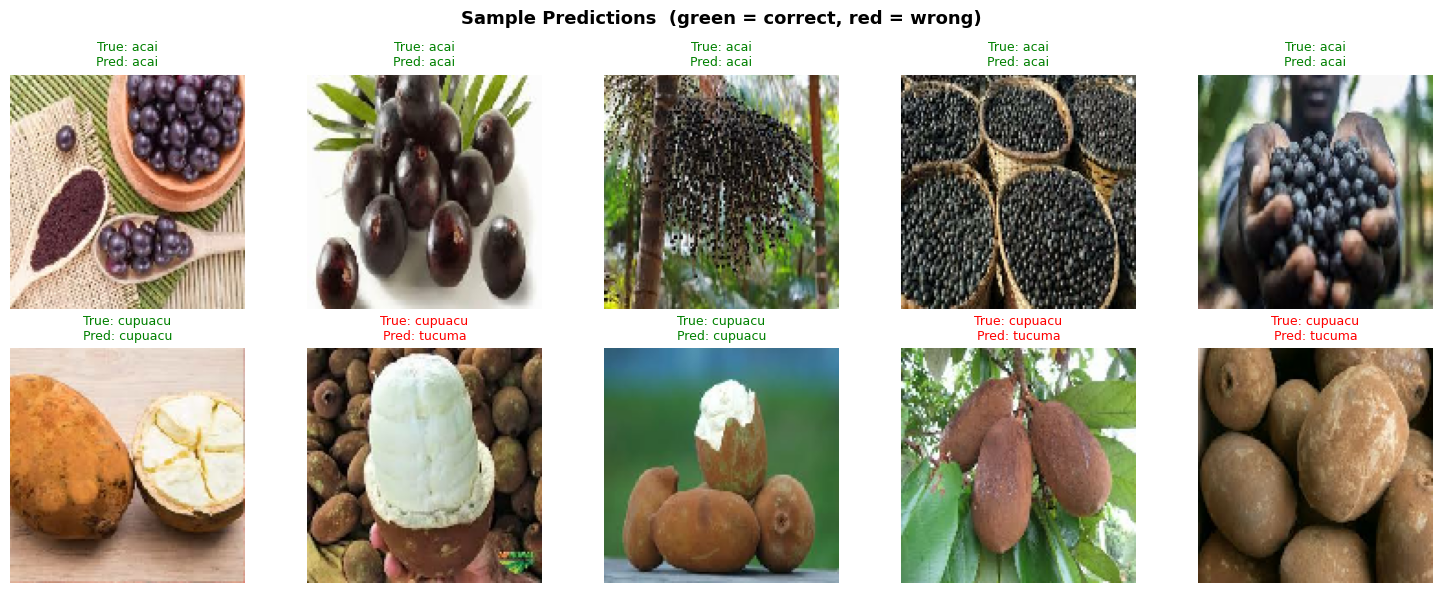

In [19]:
images_shown, labels_shown, preds_shown = [], [], []
NUM_SHOW = 10

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    for i in range(len(images)):
        if len(images_shown) >= NUM_SHOW:
            break
        images_shown.append(images[i].numpy())
        labels_shown.append(int(labels[i].numpy()))
        preds_shown.append(int(np.argmax(preds[i])))
    if len(images_shown) >= NUM_SHOW:
        break

cols = 5
rows = (NUM_SHOW + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for i in range(NUM_SHOW):
    axes[i].imshow(images_shown[i])
    true_lbl = class_names[labels_shown[i]]
    pred_lbl = class_names[preds_shown[i]]
    colour   = 'green' if true_lbl == pred_lbl else 'red'
    axes[i].set_title(f"True: {true_lbl}\nPred: {pred_lbl}",
                      color=colour, fontsize=9)
    axes[i].axis('off')

for ax in axes[NUM_SHOW:]:
    ax.axis('off')

plt.suptitle("Sample Predictions  (green = correct, red = wrong)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
print("\nAll tasks completed!")
print("  ✓ Task 1  — Visualisation & corruption check")
print("  ✓ Task 2  — Data loading & normalisation (BATCH_SIZE=16 applied at loader)")
print("  ✓ Task 3  — CNN model built (exact architecture from worksheet)")
print("  ✓ Task 4  — Compiled (Adam, sparse_CE) & trained (EarlyStopping + Checkpoint)")
print("  ✓ Task 5  — Evaluated on test set")
print("  ✓ Task 6  — Saved as 'fruit_cnn_model.h5' & reloaded")
print("  ✓ Task 7  — Classification report + prediction grid")
